In [2]:
#setup
from mlwpy import *
%matplotlib inline

diabetes = datasets.load_diabetes()

d_tts = skms.train_test_split(diabetes.data,
                              diabetes.target, 
                              test_size=.25,
                              random_state=42)

(diabetes_train_ftrs, diabetes_test_ftrs, 
 diabetes_train_tgt,  diabetes_test_tgt) = d_tts

In [3]:
weights = np.array([3.5, -2.1, .7])
print(np.sum(np.abs(weights)),
      np.sum(weights**2))

6.3 17.15


In [4]:
x_1 = np.arange(10)
m,b = 3,2
w = np.array([m,b])

x = np.c_[x_1,np.repeat(1.0,10)] #plus 1 trick

errors = np.tile(np.array([0.0,1,1,.5,.5]),2)
print(errors*errors)

print(np.dot(errors,errors))

y_true = np.dot(x,w)
y_msr = y_true + errors

D = (x,y_msr)

[0.   1.   1.   0.25 0.25 0.   1.   1.   0.25 0.25]
5.0


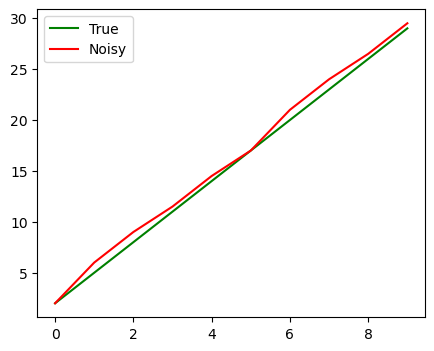

In [5]:
fig, ax = plt.subplots(1,1,figsize=(5,4))

ax.plot(x_1,y_true,'g',label='True')
ax.plot(x_1,y_msr,'r',label='Noisy')
ax.legend()


In [6]:
def sq_diff(a,b):
    return (a-b)**2

In [7]:
predictions = rdot(w,x)
np.sum(sq_diff(predictions, y_msr))
     

5.0

In [8]:
predictions = rdot(w,x)

loss = np.sum(sq_diff(predictions,y_msr))
complexity_1 = np.sum(np.abs(weights))
complexity_2 = np.sum(weights **2)

cost_1 = loss + complexity_1
cost_2 = loss + complexity_2

print("Sum(abs) complexity",cost_1)
print("Sum(abs) complexity",cost_2)
print(complexity_1)



Sum(abs) complexity 11.3
Sum(abs) complexity 22.15
6.3


In [11]:
predictions = rdot(w,x)
errors = np.sum(sq_diff(predictions,y_msr))
complexity_1 = np.sum(np.abs(weights))
C=.5
cost = errors + C*complexity_1
cost


8.15

In [13]:
models = [
    linear_model.Lasso(),
    linear_model.Ridge()
]

for model in models:
    model.fit(diabetes_train_ftrs,diabetes_train_tgt)
    train_preds = model.predict(diabetes_train_ftrs)
    test_preds = model.predict(diabetes_test_ftrs)
    print(get_model_name(model),
         "\nTrain MSE:",metrics.mean_squared_error(train_preds,diabetes_train_tgt),
         "\nTets MSE:",metrics.mean_squared_error(test_preds,diabetes_test_tgt))

Lasso 
Train MSE: 3947.9053297148935 
Tets MSE: 3433.155492119971
Ridge 
Train MSE: 3461.7437448238015 
Tets MSE: 3105.4721464484733


#### Support Vector Regression

##### Hinge Loss

Text(0, 0.5, 'RaW Error')

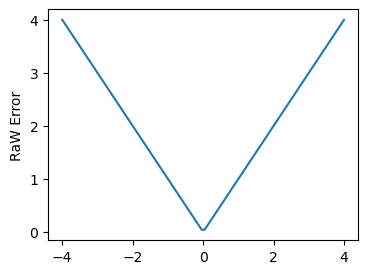

In [14]:
error = np.linspace(-4,4,100)
loss = np.abs(error)
fig,ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(error,loss)

ax.set_ylabel('Abs Error')
ax.set_ylabel('RaW Error')


In [15]:
an_error = .75
abs_error = abs(an_error)
if abs_error < 1.0:
    the_loss = 0.0
else:
    the_loss = abs_error
print(the_loss)

0.0


In [16]:

an_error = 0.75
adj_error = abs(an_error) - 1.0
if adj_error < 0.0:
    the_loss = 0.0
else:
    the_loss = adj_error
print(the_loss)
     

0.0


Text(0.5, 0, 'Raw Error')

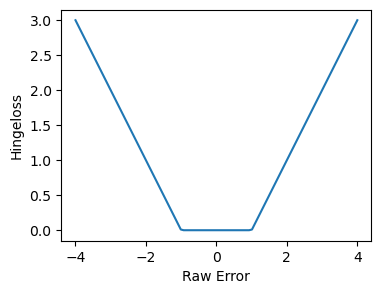

In [18]:
error = np.linspace(-4,4,100)

loss = np.maximum(np.abs(error)-1,np.zeros_like(error))

fig,ax = plt.subplots(1,1,figsize=(4,3))

ax.plot(error,loss)
ax.set_ylabel('Hingeloss')
ax.set_xlabel('Raw Error')

Text(0, 0.5, 'Output Target')

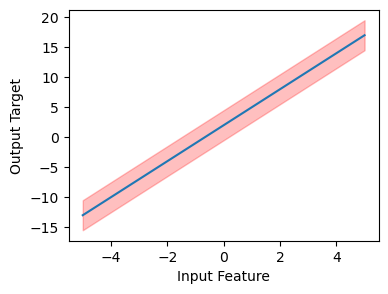

In [21]:
threshold = 2.5

xs = np.linspace(-5,5,100)
ys_true=3*xs + 2

fig,ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(xs,ys_true)
ax.fill_between(xs,ys_true-threshold,ys_true+threshold,color=(1.0,0.0,0.0,.25))

ax.set_xlabel('Input Feature')
ax.set_ylabel('Output Target')

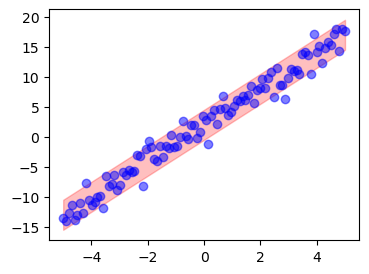

In [23]:

threshold = 2.5

xs = np.linspace(-5,5,100)
ys = 3 * xs + 2 + np.random.normal(0, 1.5, 100)

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(xs, ys, 'o',  color=(0,0,1.0,.5))
ax.fill_between(xs, ys_true - threshold, ys_true + threshold, 
                 color=(1.0,0,0,.25));

In [24]:
# hyper-parameters for the scenario
C, epsilon = 1.0, .25

# parameters
weights = np.array([1.3])

In [51]:

# prediction, error, loss
predictions = rdot(weights, xs.reshape(-1, 1))
errors = ys - predictions

loss_sse   = np.sum(errors ** 2)
loss_sae   = np.sum(np.abs(errors))
loss_hinge = np.sum(np.max(np.abs(errors) - epsilon, 0))
print(np.sum(np.abs(errors)))
print(loss_hinge)

473.38161550756644
11.771128848137334


In [52]:
complexity_saw = np.sum(np.abs(weights))
complexity_ssw = np.sum(weights**2)


In [53]:
cost_gof_regression = loss_sse + 0.0
cost_L1pen_regression = loss_sse + C * complexity_saw
cost_L2pen_regression = loss_sse + C *complexity_ssw
cost_sv_regression = loss_hinge + C *complexity_ssw


In [54]:
print(cost_gof_regression,cost_L1pen_regression,cost_L2pen_regression,cost_sv_regression)

3179.7823768670883 3181.0823768670884 3181.4723768670883 13.461128848137333


In [55]:
models = [svm.SVR(),svm.NuSVR()]

for model in models:
    preds = (model.fit(diabetes_train_ftrs, diabetes_train_tgt).predict(diabetes_test_ftrs))
    print(get_model_name(model),metrics.mean_squared_error(diabetes_test_tgt,preds))


SVR 4511.870338681655
NuSVR 4608.840546363738


#### Piecewise constant regression

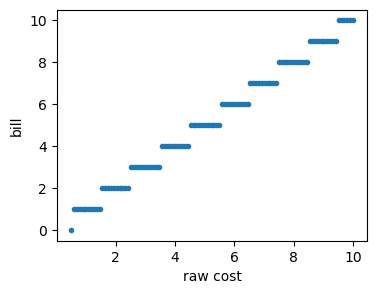

In [57]:

raw_bill = np.linspace(.5, 10.0, 100)
collected = np.round(raw_bill)

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(raw_bill, collected, '.')
ax.set_xlabel("raw cost")
ax.set_ylabel("bill");
     

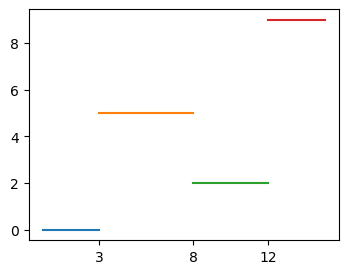

In [58]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot([0,3],   [0,0],
        [3,8],   [5,5],
        [8,12],  [2,2],
        [12,15], [9,9])
ax.set_xticks([3,8,12]);

In [59]:
dtrees = [tree.DecisionTreeRegressor(max_depth=md) for md in [1, 3, 5, 10]]

for model in dtrees:
    preds = (model.fit(diabetes_train_ftrs, diabetes_train_tgt)
                  .predict(diabetes_test_ftrs))
    mse = metrics.mean_squared_error(diabetes_test_tgt, preds)
    fmt = "{} {:2d} {:4.0f}"
    print(fmt.format(get_model_name(model),
                     model.get_params()['max_depth'],
                     mse))
     

DecisionTreeRegressor  1 4341
DecisionTreeRegressor  3 3512
DecisionTreeRegressor  5 4004
DecisionTreeRegressor 10 5454


#### Comparison of Learners: Take Three

In [125]:
student_df = pd.read_csv('portugese_student_numeric.csv')
student_ftrs = student_df[student_df.columns[:-1]]
student_tgt  = student_df['G3']

In [126]:
tts = skms.train_test_split(student_ftrs,student_tgt)
(student_train_ftrs, student_test_ftrs,student_train_tgt,student_test_tgt) = tts


In [127]:
old_school = [linear_model.LinearRegression(),
              neighbors.KNeighborsRegressor(n_neighbors=3),
              neighbors.KNeighborsRegressor(n_neighbors=10)]

In [128]:
# L1, L2 penalized (abs, sqr) C=1.0 for both
penalized_lr = [linear_model.Lasso(), 
                linear_model.Ridge()]

# defaults are epsilon=.1 and nu=.5, respectively
svrs = [svm.SVR(), svm.NuSVR()] 

dtrees = [tree.DecisionTreeRegressor(max_depth=md) for md in [1, 3, 5, 10]]

reg_models = old_school + penalized_lr + svrs + dtrees
     

In [133]:
def rms_error(actual,predicted):
    mse = metrics.mean_squared_error(actual,predicted)
    return np.sqrt(mse)

rms_scorer = metrics.make_scorer(rms_error)
print(student_tgt)

0       6
1       6
2      10
3      15
4      10
       ..
390     9
391    16
392     7
393    10
394     9
Name: G3, Length: 395, dtype: int64


In [134]:
scaler = skpre.StandardScaler()

scores = {}
for model in reg_models:
    pipe = pipeline.make_pipeline(scaler, model)
    preds = skms.cross_val_predict(pipe, 
                                   student_ftrs, student_tgt, 
                                   cv=10)
    key = (get_model_name(model) + 
           str(model.get_params().get('max_depth', "")) + 
           str(model.get_params().get('n_neighbors', "")))
    scores[key] = rms_error(student_tgt, preds)

df = pd.DataFrame.from_dict(scores, orient='index').sort_values(0)
df.columns=['RMSE']
display(df)

,RMSE
DecisionTreeRegressor1,4.3192
Ridge,4.3646
LinearRegression,4.3653
NuSVR,4.3896
SVR,4.4062
DecisionTreeRegressor3,4.4298
Lasso,4.4375
KNeighborsRegressor10,4.4869
DecisionTreeRegressor5,4.8303
KNeighborsRegressor3,4.8915


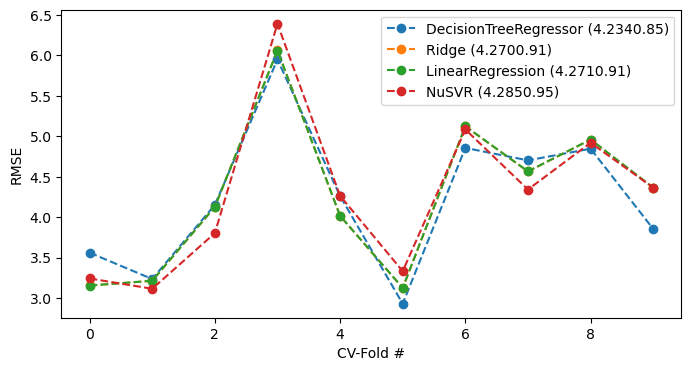

In [136]:
better_models = [tree.DecisionTreeRegressor(max_depth=1),
                 linear_model.Ridge(),
                 linear_model.LinearRegression(),
                 svm.NuSVR()]

fig, ax = plt.subplots(1, 1, figsize=(8,4))
for model in better_models:
    pipe = pipeline.make_pipeline(scaler, model)    
    cv_results = skms.cross_val_score(pipe, 
                                      student_ftrs, student_tgt, 
                                      scoring = rms_scorer, 
                                      cv=10)

    my_lbl = "{:s} ({:5.3f}{:.2f})".format(get_model_name(model), 
                                                cv_results.mean(), 
                                                cv_results.std())
    ax.plot(cv_results, 'o--', label=my_lbl)
    ax.set_xlabel('CV-Fold #')
    ax.set_ylabel("RMSE")
    ax.legend()